# 1、使用@tool装饰器定义工具

举例1：

In [4]:
from langchain_core.tools import tool, StructuredTool
from pydantic import BaseModel


@tool
def add_number(a: int, b: int) -> int:
    """计算两个整数的和"""
    return a + b


print(f"name = {add_number.name}")  #默认是函数的名称
print(f"args = {add_number.args}")
print(f"description = {add_number.description}")  #默认是函数的说明信息
print(f"return_direct = {add_number.return_direct}")  #默认值是False


name = add_number
args = {'a': 'int', 'b': 'int'}
description = 计算两个整数的和
return_direct = False


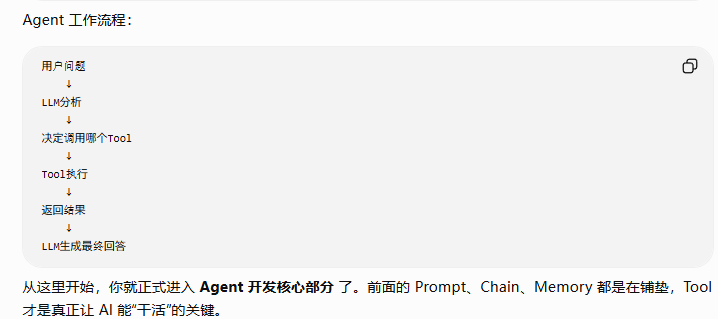

举例2：


In [5]:
from langchain_core.tools import tool


@tool(name_or_callable="add_two_number", description="add two numbers", return_direct=True)
def add_number(a: int, b: int) -> int:
    """计算两个整数的和"""
    return a + b


print(f"name = {add_number.name}")  #add_two_number
print(f"args = {add_number.args}")
print(f"description = {add_number.description}")  #add two numbers
print(f"return_direct = {add_number.return_direct}")  #True





name = add_two_number
args = {'a': 'int', 'b': 'int'}
description = add two numbers
return_direct = True


In [6]:
#调用工具
add_number.invoke({"a": 10, "b": 20})


30

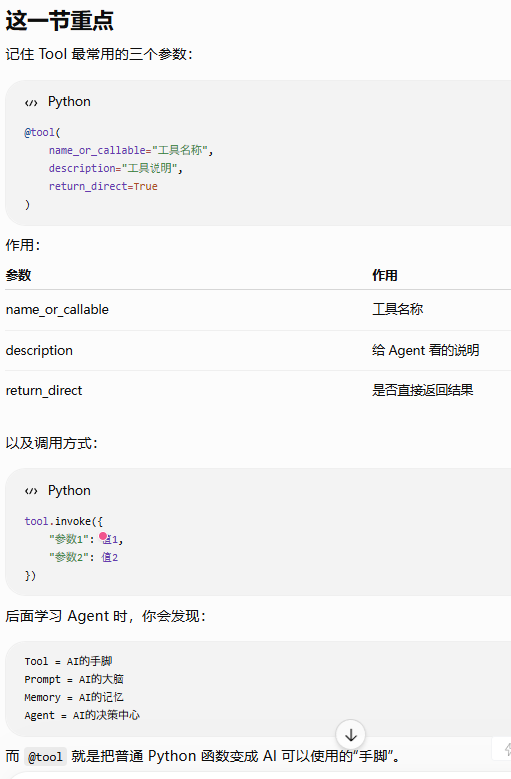

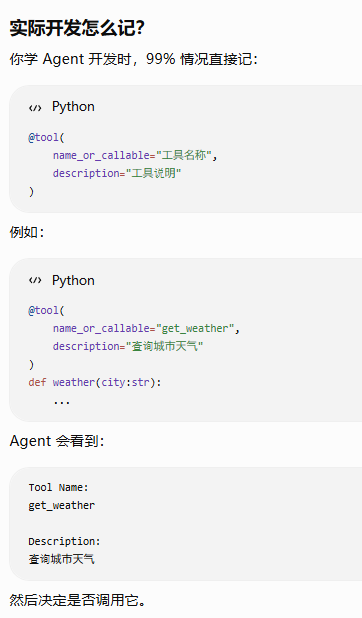

举例3：修改args参数的描述

In [9]:
from pydantic import Field
from langchain_core.tools import tool
from pydantic import BaseModel


class FieldInfo(BaseModel):
    a: int = Field(description="第1个整型参数")
    b: int = Field(description="第2个整型参数")


@tool(name_or_callable="add_two_number", description="add two numbers", return_direct=True, args_schema=FieldInfo)
def add_number(a: int, b: int) -> int:
    """计算两个整数的和"""
    return a + b


print(f"name = {add_number.name}")  #add_two_number
print(f"args = {add_number.args}")
print(f"description = {add_number.description}")  #add two numbers
print(f"return_direct = {add_number.return_direct}")  #True

name = add_two_number
args = {'a': '第1个整型参数', 'b': '第2个整型参数'}
description = add two numbers
return_direct = True


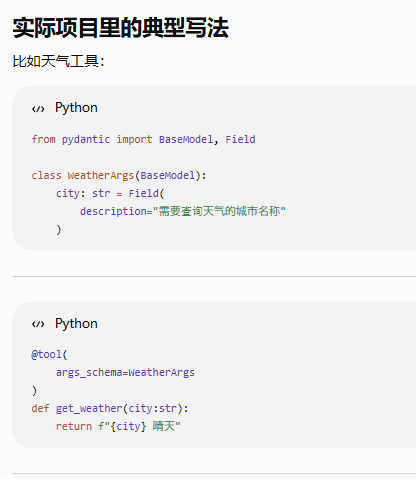

# 2、StructuredTool的from_function()的使用

举例1：

In [10]:
from langchain_core.tools.structured import StructuredTool


# 声明一个函数
def search_google(query: str):
    return "最后查询的结果"


# 定义一个工具
search01 = StructuredTool.from_function(
    func=search_google,
    name="Search",
    description="查询google搜索引擎，并将结果返回"
)

print(f"name = {search01.name}")
print(f"args = {search01.args}")
print(f"description = {search01.description}")
print(f"return_direct = {search01.return_direct}")

name = Search
args = {'query': 'str'}
description = 查询google搜索引擎，并将结果返回
return_direct = False


In [11]:
search01.invoke({"query":"中美AI的发展现状"})

'最后查询的结果'

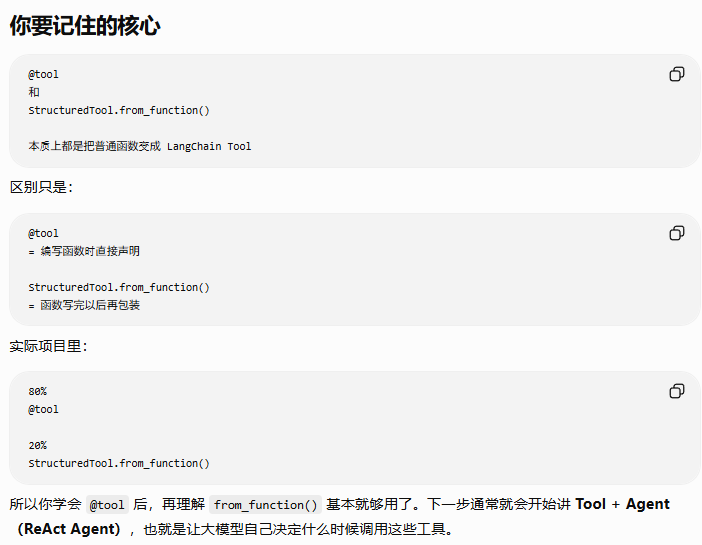

举例2：


In [12]:
from langchain_core.tools.structured import StructuredTool
from pydantic import BaseModel,Field

class FieldInfo(BaseModel):
    query: str = Field(description="要检索的关键词")


# 声明一个函数
def search_google(query: str):
    return "最后查询的结果"


# 定义一个工具
search02 = StructuredTool.from_function(
    func=search_google,
    name="Search",
    description="查询google搜索引擎，并将结果返回",
    return_direct=True,
    args_schema=FieldInfo
)

print(f"name = {search02.name}")
print(f"args = {search02.args}")
print(f"description = {search02.description}")
print(f"return_direct = {search02.return_direct}")

name = Search
args = {'query': '要检索的关键词'}
description = 查询google搜索引擎，并将结果返回
return_direct = True


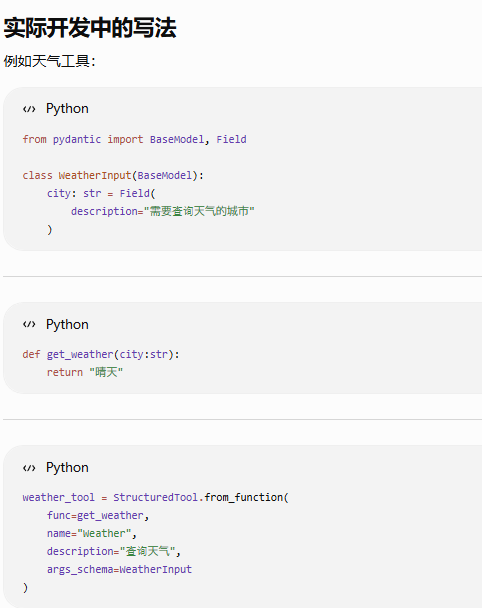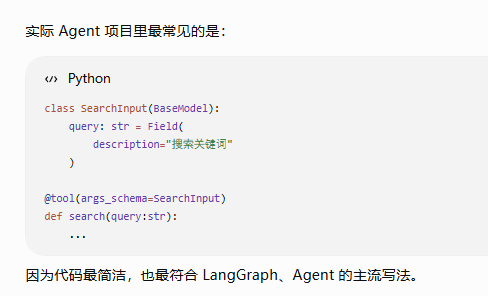